# **1. Perkenalan Dataset**


## Dataset: Titanic - Machine Learning from Disaster

**Sumber Dataset:** [Kaggle - Titanic Dataset](https://www.kaggle.com/datasets/yasserh/titanic-dataset)

**Deskripsi:**  
Dataset Titanic berisi informasi penumpang kapal RMS Titanic yang tenggelam pada 15 April 1912. Dataset ini digunakan untuk memprediksi apakah seorang penumpang selamat (`Survived = 1`) atau tidak (`Survived = 0`) berdasarkan fitur-fitur seperti usia, jenis kelamin, kelas tiket, dan lain-lain.

**Informasi Dataset:**
- **Jumlah baris:** 891
- **Jumlah kolom:** 12
- **Task:** Binary Classification (Survived / Not Survived)
- **Target kolom:** `Survived`

**Fitur-fitur:**

| Kolom | Deskripsi |
|---|---|
| PassengerId | ID unik penumpang |
| Survived | 0 = Tidak selamat, 1 = Selamat (target) |
| Pclass | Kelas tiket (1 = First, 2 = Second, 3 = Third) |
| Name | Nama penumpang |
| Sex | Jenis kelamin |
| Age | Usia penumpang |
| SibSp | Jumlah saudara/pasangan di kapal |
| Parch | Jumlah orang tua/anak di kapal |
| Ticket | Nomor tiket |
| Fare | Harga tiket |
| Cabin | Nomor kabin |
| Embarked | Pelabuhan keberangkatan (C=Cherbourg, Q=Queenstown, S=Southampton) |

# **2. Import Library**

Mengimpor pustaka Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [2]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 125.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 129.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 907.5/907.5 kB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)

# MLflow
import mlflow
import mlflow.sklearn

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print('Semua library berhasil diimport!')
print(f'MLflow version: {mlflow.__version__}')

Semua library berhasil diimport!
MLflow version: 3.13.0


# **3. Memuat Dataset**

Memuat dataset Titanic ke dalam notebook menggunakan pandas.

In [4]:
# Load dataset langsung dari URL (seeder Kaggle/GitHub mirror)
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Simpan dataset raw ke file lokal
df.to_csv('titanic_raw.csv', index=False)
print('Dataset berhasil dimuat dan disimpan sebagai titanic_raw.csv')
print(f'Ukuran dataset: {df.shape[0]} baris x {df.shape[1]} kolom')
print()
print('5 baris pertama dataset:')
df.head()

Dataset berhasil dimuat dan disimpan sebagai titanic_raw.csv
Ukuran dataset: 891 baris x 12 kolom

5 baris pertama dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Cek tipe data dan info umum
print('=== INFO DATASET ===')
df.info()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# Statistik deskriptif
print('=== STATISTIK DESKRIPTIF ===')
df.describe()

=== STATISTIK DESKRIPTIF ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# **4. Exploratory Data Analysis (EDA)**

Melakukan eksplorasi data untuk memahami karakteristik dataset sebelum preprocessing dan pemodelan.

In [7]:
# 4.1 Cek Missing Values
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

=== MISSING VALUES ===
          Missing Count  Missing %
Cabin               687  77.104377
Age                 177  19.865320
Embarked              2   0.224467


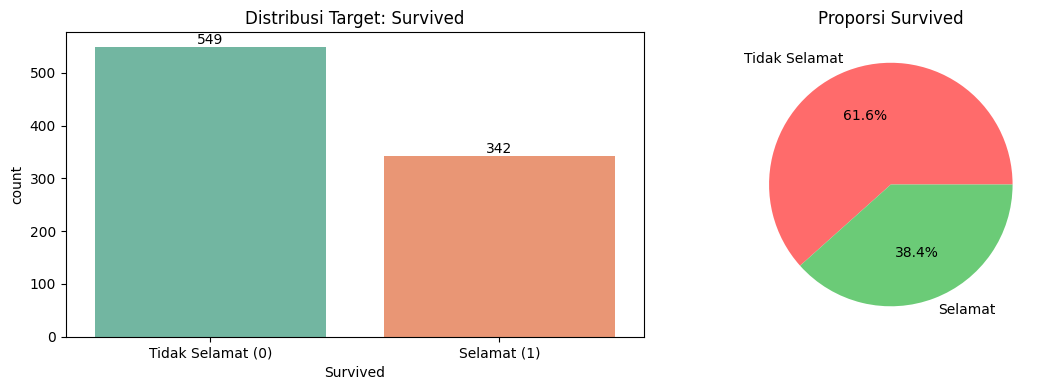

Survived
0    549
1    342
Name: count, dtype: int64


In [8]:
# 4.2 Distribusi Target (Survived)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(data=df, x='Survived', palette='Set2', ax=axes[0])
axes[0].set_title('Distribusi Target: Survived')
axes[0].set_xticklabels(['Tidak Selamat (0)', 'Selamat (1)'])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom')

# Pie chart
df['Survived'].value_counts().plot(kind='pie', ax=axes[1],
                                    labels=['Tidak Selamat', 'Selamat'],
                                    autopct='%1.1f%%',
                                    colors=['#ff6b6b', '#6bcb77'])
axes[1].set_title('Proporsi Survived')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print(df['Survived'].value_counts())

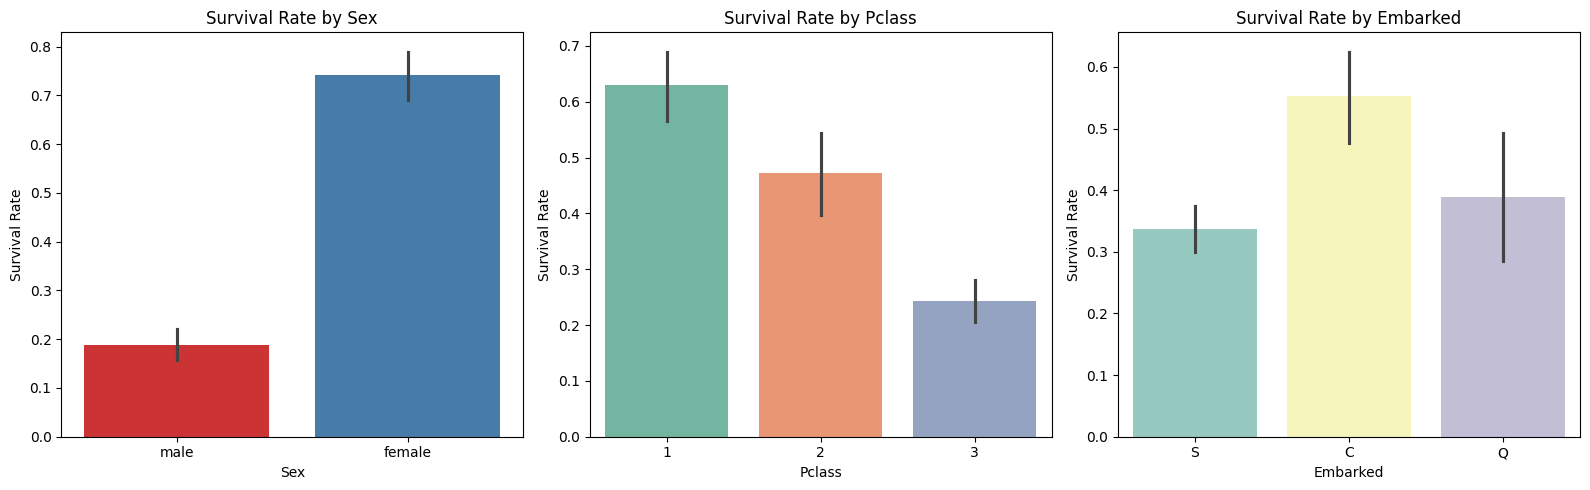

In [9]:
# 4.3 Survival Rate berdasarkan fitur kategorik
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Survival by Sex
sns.barplot(data=df, x='Sex', y='Survived', palette='Set1', ax=axes[0])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')

# Survival by Pclass
sns.barplot(data=df, x='Pclass', y='Survived', palette='Set2', ax=axes[1])
axes[1].set_title('Survival Rate by Pclass')
axes[1].set_ylabel('Survival Rate')

# Survival by Embarked
sns.barplot(data=df, x='Embarked', y='Survived', palette='Set3', ax=axes[2])
axes[2].set_title('Survival Rate by Embarked')
axes[2].set_ylabel('Survival Rate')

plt.tight_layout()
plt.savefig('eda_categorical_survival.png', dpi=100, bbox_inches='tight')
plt.show()

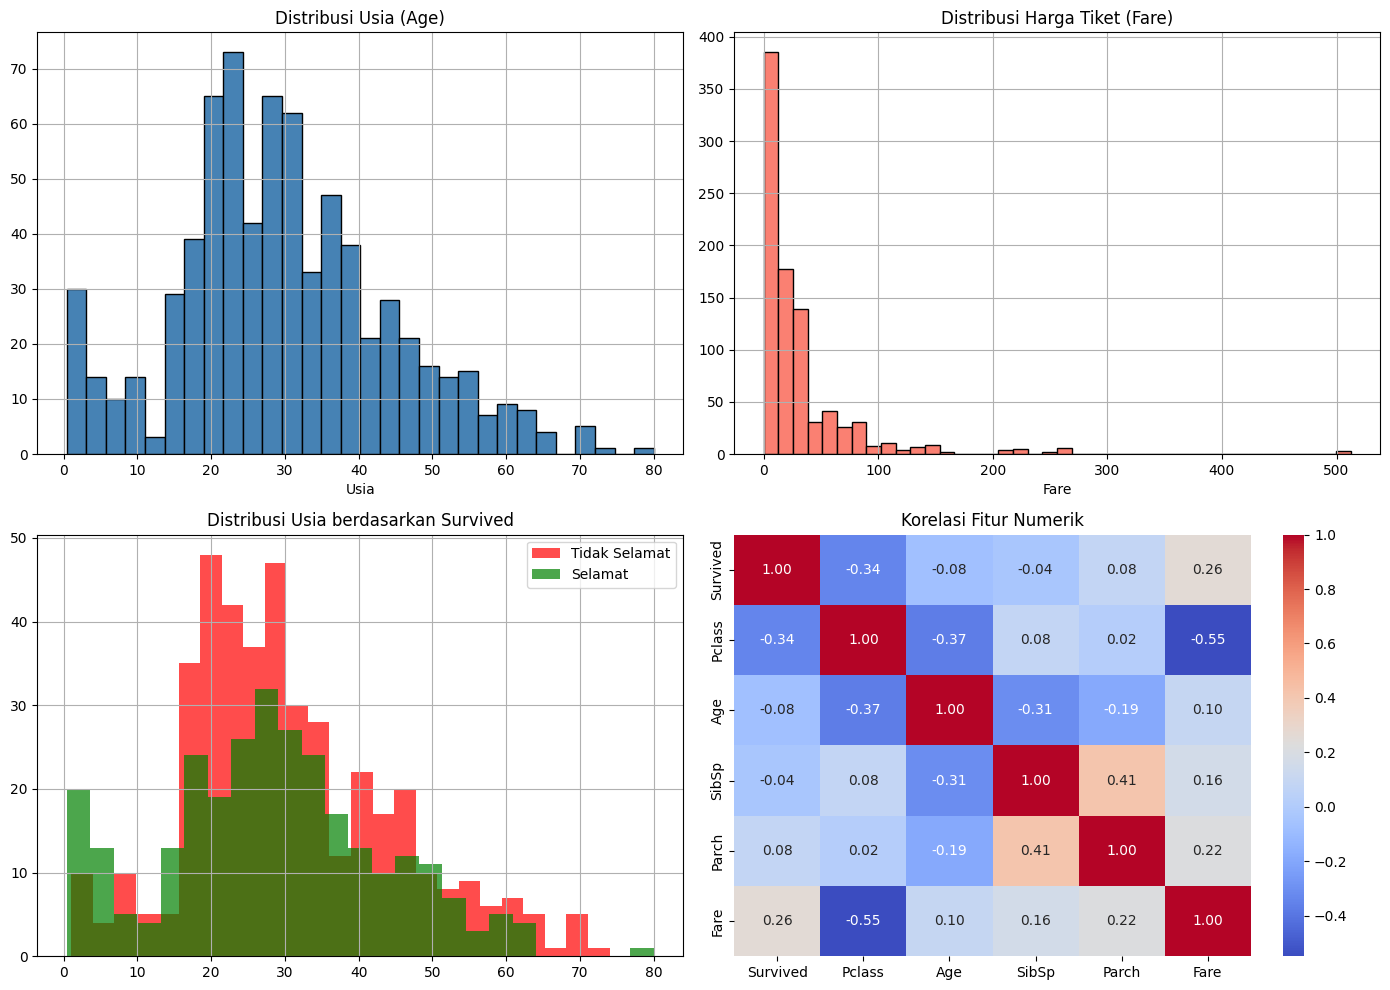

In [10]:
# 4.4 Distribusi fitur numerik
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
df['Age'].dropna().hist(bins=30, ax=axes[0,0], color='steelblue', edgecolor='black')
axes[0,0].set_title('Distribusi Usia (Age)')
axes[0,0].set_xlabel('Usia')

# Fare distribution
df['Fare'].hist(bins=40, ax=axes[0,1], color='salmon', edgecolor='black')
axes[0,1].set_title('Distribusi Harga Tiket (Fare)')
axes[0,1].set_xlabel('Fare')

# Age by Survived
df[df['Survived']==0]['Age'].dropna().hist(bins=25, ax=axes[1,0], alpha=0.7,
                                            label='Tidak Selamat', color='red')
df[df['Survived']==1]['Age'].dropna().hist(bins=25, ax=axes[1,0], alpha=0.7,
                                            label='Selamat', color='green')
axes[1,0].set_title('Distribusi Usia berdasarkan Survived')
axes[1,0].legend()

# Correlation heatmap numerik
corr_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('Korelasi Fitur Numerik')

plt.tight_layout()
plt.savefig('eda_numerical.png', dpi=100, bbox_inches='tight')
plt.show()

**Insight dari EDA:**
- Dataset memiliki **imbalance class** (~61.6% tidak selamat, ~38.4% selamat)
- **Wanita** memiliki survival rate jauh lebih tinggi dibanding pria
- **Kelas 1** (first class) memiliki survival rate tertinggi
- Kolom `Age` memiliki ~19.9% missing values, `Cabin` memiliki ~77% missing values
- Fitur `Fare` dan `Pclass` berkorelasi negatif (kelas lebih tinggi = harga lebih mahal)

# **5. Data Preprocessing**

Membersihkan dan mempersiapkan data agar siap digunakan untuk pemodelan.

In [11]:
# 5.1 Copy dataframe agar data asli tetap tersimpan
df_clean = df.copy()

# 5.2 Drop kolom yang tidak relevan
# PassengerId, Name, Ticket, Cabin tidak berkontribusi signifikan
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_clean = df_clean.drop(columns=drop_cols)
print(f'Kolom setelah drop: {list(df_clean.columns)}')

Kolom setelah drop: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [12]:
# 5.3 Handling Missing Values
print('Missing values sebelum handling:')
print(df_clean.isnull().sum())

# Age: isi dengan median
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)

# Embarked: isi dengan modus (nilai paling sering muncul)
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

print('\nMissing values setelah handling:')
print(df_clean.isnull().sum())

Missing values sebelum handling:
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

Missing values setelah handling:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [13]:
# 5.4 Encoding Fitur Kategorik
le = LabelEncoder()

# Sex: male=1, female=0
df_clean['Sex'] = le.fit_transform(df_clean['Sex'])

# Embarked: C=0, Q=1, S=2
df_clean['Embarked'] = le.fit_transform(df_clean['Embarked'])

print('Encoding selesai. Cek 5 baris pertama:')
df_clean.head()

Encoding selesai. Cek 5 baris pertama:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [14]:
# 5.5 Feature Engineering - Tambah fitur FamilySize
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)

print('Fitur baru berhasil ditambahkan:')
print(df_clean[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head(10))

Fitur baru berhasil ditambahkan:
   SibSp  Parch  FamilySize  IsAlone
0      1      0           2        0
1      1      0           2        0
2      0      0           1        1
3      1      0           2        0
4      0      0           1        1
5      0      0           1        1
6      0      0           1        1
7      3      1           5        0
8      0      2           3        0
9      1      0           2        0


In [15]:
# 5.6 Pisahkan Fitur (X) dan Target (y)
X = df_clean.drop(columns=['Survived'])
y = df_clean['Survived']

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'\nFitur yang digunakan: {list(X.columns)}')

Shape X: (891, 9)
Shape y: (891,)

Fitur yang digunakan: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']


In [16]:
# 5.7 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set: {X_train.shape[0]} baris')
print(f'Test set:  {X_test.shape[0]} baris')

Train set: 712 baris
Test set:  179 baris


In [17]:
# 5.8 Normalisasi Fitur Numerik
scaler = StandardScaler()
scale_cols = ['Age', 'Fare', 'FamilySize']

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

print('Normalisasi selesai!')
print('\nContoh data train setelah preprocessing:')
X_train.head()

Normalisasi selesai!

Contoh data train setelah preprocessing:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
692,3,1,-0.112078,0,0,0.513812,2,-0.556339,1
481,2,1,-0.112078,0,0,-0.662563,2,-0.556339,1
527,1,1,-0.112078,0,0,3.955399,2,-0.556339,1
855,3,0,-0.879807,0,1,-0.467874,2,0.073412,0
801,2,0,0.118241,1,1,-0.115977,2,0.703162,0


In [18]:
# 5.9 Simpan hasil preprocessing ke CSV
df_preprocessed = X_train.copy()
df_preprocessed['Survived'] = y_train.values
df_preprocessed.to_csv('titanic_preprocessing.csv', index=False)

print('Dataset hasil preprocessing disimpan sebagai titanic_preprocessing.csv')
print(f'Shape: {df_preprocessed.shape}')

Dataset hasil preprocessing disimpan sebagai titanic_preprocessing.csv
Shape: (712, 10)


# **6. Pembuatan Model dengan MLflow Tracking**

Melatih model machine learning dengan MLflow untuk mencatat eksperimen secara otomatis.

In [19]:
# Setup MLflow experiment
mlflow.set_experiment('Titanic-Survival-Prediction')
print('MLflow experiment berhasil dibuat: Titanic-Survival-Prediction')

2026/06/08 06:53:23 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/08 06:53:23 INFO mlflow.store.db.utils: Updating database tables
2026/06/08 06:53:25 INFO mlflow.tracking.fluent: Experiment with name 'Titanic-Survival-Prediction' does not exist. Creating a new experiment.


MLflow experiment berhasil dibuat: Titanic-Survival-Prediction


In [20]:
# === Eksperimen 1: Logistic Regression ===
with mlflow.start_run(run_name='LogisticRegression'):
    # Parameter
    params = {'C': 1.0, 'max_iter': 200, 'random_state': 42}

    # Train
    model_lr = LogisticRegression(**params)
    model_lr.fit(X_train, y_train)
    y_pred_lr = model_lr.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred_lr)
    auc = roc_auc_score(y_test, model_lr.predict_proba(X_test)[:,1])

    # Log ke MLflow
    mlflow.log_params(params)
    mlflow.log_metric('accuracy', acc)
    mlflow.log_metric('roc_auc', auc)
    mlflow.sklearn.log_model(model_lr, 'model')

    print(f'[Logistic Regression] Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f}')
    print(classification_report(y_test, y_pred_lr))

2026/06/08 06:53:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 06:53:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Logistic Regression] Accuracy: 0.8045 | ROC-AUC: 0.8590
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [21]:
# === Eksperimen 2: Random Forest - default ===
with mlflow.start_run(run_name='RandomForest_default'):
    params = {'n_estimators': 100, 'random_state': 42}

    model_rf = RandomForestClassifier(**params)
    model_rf.fit(X_train, y_train)
    y_pred_rf = model_rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred_rf)
    auc = roc_auc_score(y_test, model_rf.predict_proba(X_test)[:,1])

    mlflow.log_params(params)
    mlflow.log_metric('accuracy', acc)
    mlflow.log_metric('roc_auc', auc)
    mlflow.sklearn.log_model(model_rf, 'model')

    print(f'[RF Default] Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f}')
    print(classification_report(y_test, y_pred_rf))

2026/06/08 06:53:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 06:53:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF Default] Accuracy: 0.8045 | ROC-AUC: 0.8337
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       110
           1       0.76      0.72      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [22]:
# === Eksperimen 3: Random Forest - tuned ===
with mlflow.start_run(run_name='RandomForest_tuned'):
    params = {
        'n_estimators': 200,
        'max_depth': 8,
        'min_samples_split': 4,
        'min_samples_leaf': 2,
        'random_state': 42
    }

    model_rf_tuned = RandomForestClassifier(**params)
    model_rf_tuned.fit(X_train, y_train)
    y_pred_rf_tuned = model_rf_tuned.predict(X_test)

    acc = accuracy_score(y_test, y_pred_rf_tuned)
    auc = roc_auc_score(y_test, model_rf_tuned.predict_proba(X_test)[:,1])

    mlflow.log_params(params)
    mlflow.log_metric('accuracy', acc)
    mlflow.log_metric('roc_auc', auc)
    mlflow.sklearn.log_model(model_rf_tuned, 'model')

    print(f'[RF Tuned] Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f}')
    print(classification_report(y_test, y_pred_rf_tuned))

2026/06/08 06:54:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 06:54:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF Tuned] Accuracy: 0.8101 | ROC-AUC: 0.8407
              precision    recall  f1-score   support

           0       0.81      0.91      0.85       110
           1       0.82      0.65      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179



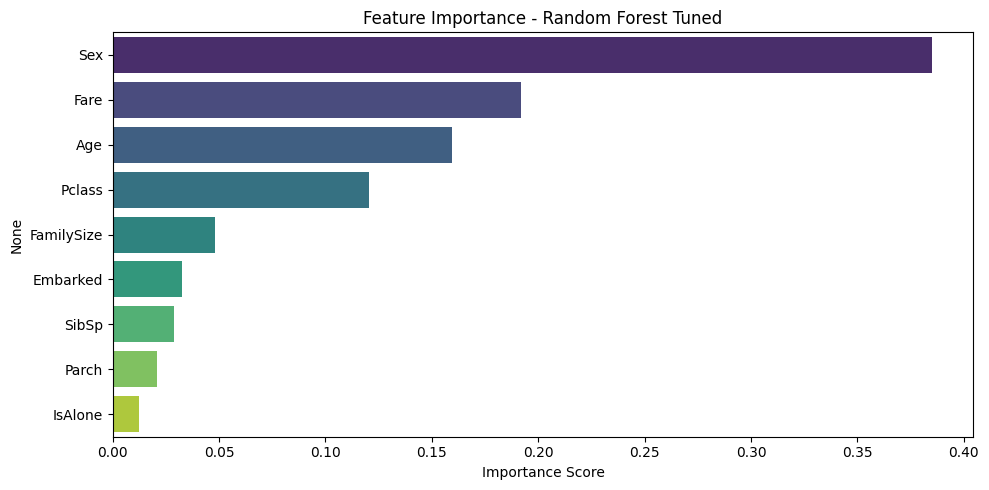


Feature Importance:
Sex           0.385222
Fare          0.191947
Age           0.159509
Pclass        0.120456
FamilySize    0.048054
Embarked      0.032719
SibSp         0.028927
Parch         0.020842
IsAlone       0.012324
dtype: float64


In [23]:
# Visualisasi Feature Importance (model terbaik: RF Tuned)
feat_imp = pd.Series(
    model_rf_tuned.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Feature Importance - Random Forest Tuned')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nFeature Importance:')
print(feat_imp)

In [24]:
# Tampilkan semua eksperimen MLflow
print('=== RINGKASAN EKSPERIMEN MLflow ===')
print('Jalankan perintah berikut di terminal untuk membuka UI MLflow:')
print('  mlflow ui')
print('Lalu buka browser ke: http://127.0.0.1:5000')

# List runs
experiment = mlflow.get_experiment_by_name('Titanic-Survival-Prediction')
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
print('\nDaftar run yang tersimpan:')
print(runs[['run_id', 'tags.mlflow.runName', 'metrics.accuracy', 'metrics.roc_auc']].to_string())

=== RINGKASAN EKSPERIMEN MLflow ===
Jalankan perintah berikut di terminal untuk membuka UI MLflow:
  mlflow ui
Lalu buka browser ke: http://127.0.0.1:5000

Daftar run yang tersimpan:
                             run_id   tags.mlflow.runName  metrics.accuracy  metrics.roc_auc
0  e1ad0628cb4241c68c87544eee232de5    RandomForest_tuned          0.810056         0.840711
1  363869bc9de64bc5b4ba756e691734d6  RandomForest_default          0.804469         0.833729
2  aca332fb53504bdd8df37b878a1d08d3    LogisticRegression          0.804469         0.859025
